# 机器学习示例


## 介绍  
当下世界每时每刻都有海量数据产生，为了应对这种海量数据涌入，数据科学领域在过去二十年中走在了前列。数据科学领域由**统计学、物理学、计算机科学、设计**等不同领域的人们拼凑而成，代表了理解和利用周围大量数据来构建更美好世界的共同愿望。
本笔记本中，将从头到尾介绍展示典型的数据科学工作流是什么样的。

## 依赖包

本笔记本使用 Anaconda Python 发行版标配的多个 Python 软件包。

* **NumPy**: Provides a fast numerical array structure and helper functions.
* **pandas**: Provides a DataFrame structure to store data in memory and work with it easily and efficiently.
* **scikit-learn**: The essential Machine Learning package in Python.
* **matplotlib**: Basic plotting library in Python; most other Python plotting libraries are built on top of it.
* **Seaborn**: Advanced statistical plotting library.

确保已使用 `conda`安装所依赖的软件包:

    conda install numpy pandas scikit-learn matplotlib seaborn


## 问题域

下面将创建一个演示机器学习模型，该模型从鸢尾花朵中获取四个测量值（萼片长度、萼片宽度、花瓣长度和花瓣宽度），并仅根据这些测量值来识别物种。

<img src="images/petal_sepal.jpg" width="400" height="400"/>

三种鸢尾花的测量值：

###*Iris setosa*  
<img src="images/iris_setosa.jpg" width="300" height="300"/>

###*Iris versicolor*  
<img src="images/iris_versicolor.jpg" width="300" height="300"/>

###*Iris virginica*  
<img src="images/iris_virginica.jpg" width="300" height="300"/>

注：正在使用的数据集是著名的 Iris 数据集（包含在此笔记本中），为了演示目的，对其进行了轻微修改。

## step 1 理解需求  

任何数据分析项目的第一步都是定义我们想要解决的问题，并定义我们成功解决该任务的衡量标准（或一组衡量标准）。数据分析清单让我们回答一些问题来实现这一目标，所以让我们来回答这些问题。

>在接触数据之前，是否指定了数据分析问题的类型（例如探索、关联因果关系）？

我们试图根据提供的四个测量值（萼片长度、萼片宽度、花瓣长度和花瓣宽度）对花的种类（即类别）进行分类。

>在开始之前，是否定义了成功的指标？

由于我们是需分类，因此我们可以使用准确率（正确分类的花朵的比例）来量化模型的性能。且我们应该至少达到 90% 的准确率。

>会记录了实验设计吗？

实地研究人员正在使用标准化方法手工测量每个物种的 50 朵随机抽样的花朵。实地研究人员从预定义的角度为他们采样的每朵花拍照，以便其他实地研究人员稍后可以确认测量值和种类。

>用现有数据可以回答什么问题?

目前拥有的数据集仅适用于三种类型的鸢尾花。基于此数据集构建的模型仅适用于那些鸢尾花，因此我们需要更多数据来创建通用的花卉分类器。

<hr />

注意，此时我们花了相当多的时间来解决问题（理解需求），而没有编写一行代码，甚至没有查看数据。


## Step 2: 检查数据

第二步，查看正在处理的数据。数据可能存在错误，在投入太多时间进行分析之前发现这些错误至关重要。  
一般来说，我们希望回答以下问题：  
>数据有什么问题吗？  

>数据有什么特别吗？  

>我是否需要修复或删除任何数据？  

让我们首先将数据读入至pandas DataFrame中。


In [1]:
import pandas as pd

iris_data = pd.read_csv('iris-data.csv')
iris_data.head()

,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


很幸运！数据似乎采用可用格式，并且前几行没看出有异常数据。  

数据文件中的第一行定义了列标题，标题具有足够的描述性，可以让我们能够理解每列所代表的内容。标题甚至为我们提供了记录测量值的单位，以防万一我们在项目后期需要知道。  
第一行之后的每一行代表一朵花的一个条目：四个测量值和一个类，它告诉我们花的种类。  
**研究数据的第一件事是看有没有缺失的数据。**值得庆幸的是，现场研究人员已经告诉我们，当他们缺少测量时，他们会在电子表格中输入“NA”。  
如果 pandas 知道我们的缺失值标记，我们可以告诉 pandas 自动识别缺失值。

In [2]:
iris_data = pd.read_csv('iris-data.csv', na_values=['NA'])

用上面程序处理后带有 'NA' 的行视为缺失值。  
接下来，查看我们数据的分布 — 尤其是异常值。  
让我们首先打印出有关数据集的一些摘要统计信息。  数据集的一些摘要统计信息。

In [3]:
iris_data.describe()

,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm
count,150.000000,150.000000,150.000000,145.000000
mean,5.644627,3.054667,3.758667,1.236552
std,1.312781,0.433123,1.764420,0.755058
min,0.055000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.400000
50%,5.700000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


从此表中看到几个有用的值。例如，我们看到缺少5个petal_width_cm 条目（其他列的count值都是150）。  
通常，以某种方式可视化数据会更好。可视化使异常值和错误立即脱颖而出，而它们在大型数字表中可能会被忽视。因此我们可以设置笔记本，以便我在其中绘图。

In [4]:
# This line tells the notebook to show plots inside of the notebook
%matplotlib inline

import matplotlib.pyplot as plt
import seaborn as sb

接下来，让我们创建一个**散点图矩阵**。散点图矩阵沿对角线绘制每列的分布，然后为每个变量的组合绘制散点图矩阵。它们是查找数据中的错误的有效工具。  
我们甚至可以让绘图包按类为每个条目着色，以查找类内的趋势。

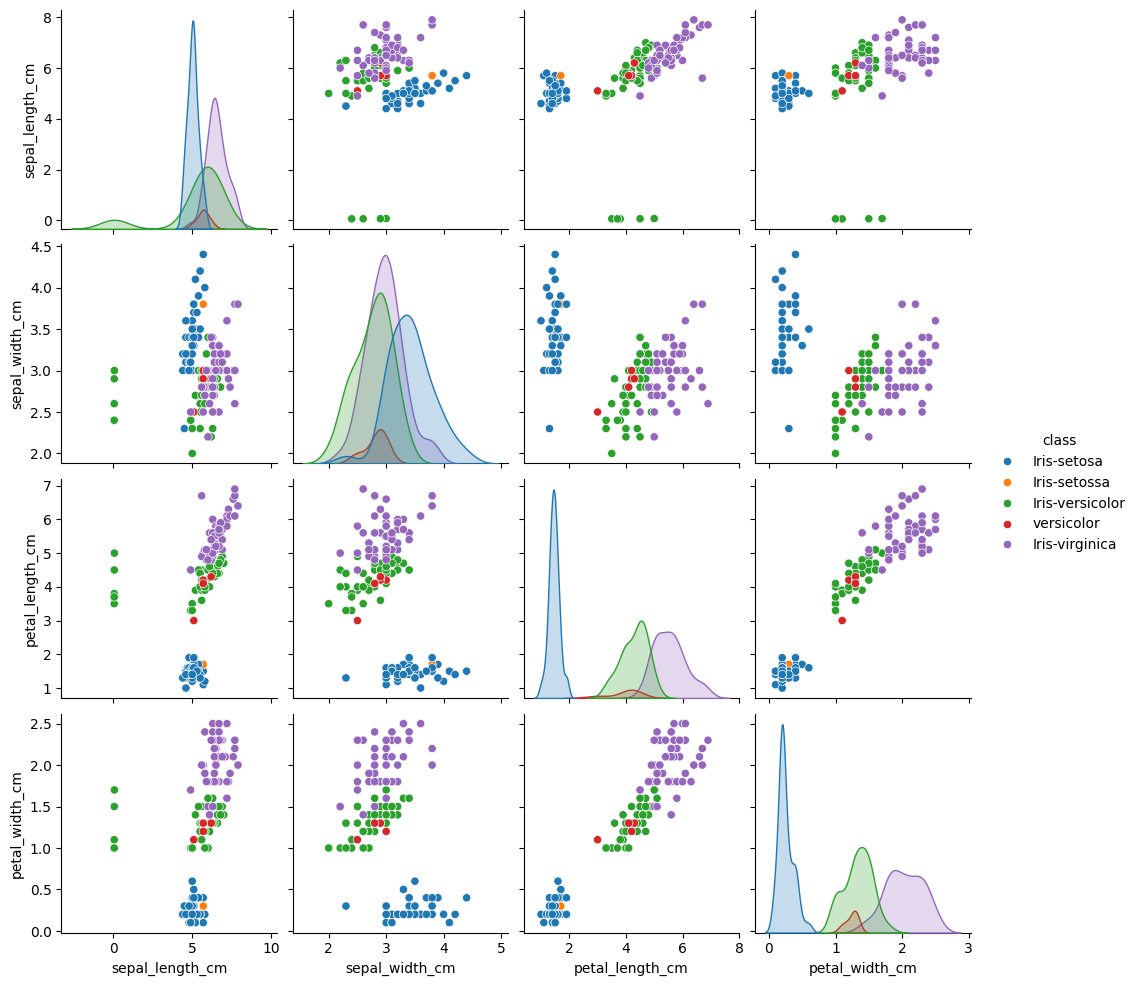

In [5]:
# We have to temporarily drop the rows with 'NA' values
# because the Seaborn plotting function does not know
# what to do with them
sb.pairplot(iris_data.dropna(), hue='class')

从散点图矩阵中，我们已经可以看到数据集的一些问题：  
当前有五个分类，而实际应该只有三个，这意味着存在一些编码错误。  
测量中有一些明显的异常值可能是错误的：鸢尾花的一个sepal_width_cm条目远远超出其正常范围，而花斑鸢尾花的几个sepal_length_cm条目由于某种原因接近于零。
因此我们不得不删除那些缺少值的行。  
在所有这些情况下，我们都需要弄清楚如何处理错误数据。这样才能进入到下一步......我们带到下一步......

## Step 3: 整理数据  
[[ go back to the top ]](## 介绍)

现在我们已经确定了数据集中的几个错误，我们需要在继续分析之前修复它们。  
让我们逐一解决这些问题。  
>有五个类，而应该只有三个，这意味着存在一些编码错误。

在与现场研究人员交谈后，听起来他们中的一个人忘记在他们的 Iris-versicolor 条目之前添加 Iris-。另一个无关的类，Iris-setossa，只是一个他们忘记纠正的错别字。

因此让我们使用 DataFrame 来修复这些错误。

In [6]:
iris_data.loc[iris_data['class'] == 'versicolor', 'class'] = 'Iris-versicolor'
iris_data.loc[iris_data['class'] == 'Iris-setossa', 'class'] = 'Iris-setosa'

iris_data['class'].unique()

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

现在我们只有三种类型。如果创建一个使用错误类的模型，那将是多么尴尬。

>测量中有一些明显的异常值可能是错误的：`Iris-setosa`的一个样本的`sepal_width_cm`远远超出其正常范围，而`Iris-versicolor`的几个`sepal_length_cm`条目由于某种原因接近于零。

修复异常值可能是一项棘手的工作。很少能清楚异常值是由测量误差引起的，还是以不正确的单位记录数据，或者异常值是否是真正的异常。因此，我们在处理异常值时应该谨慎：如果我们决定排除任何数据，我们需要确保记录我们排除的数据，并提供排除该数据的可靠理由。（即，“此数据不符合我的假设”是否经得起同行评审。）

在处理`Iris-setosa`的异常条目时，假设我们的研究人员知道`Iris-setosa`的萼片宽度不可能低于 2.5 厘米。显然，这个条目是错误的，我们最好直接废弃这个条目，而不是花几个小时找出发生了什么。

<Axes: >

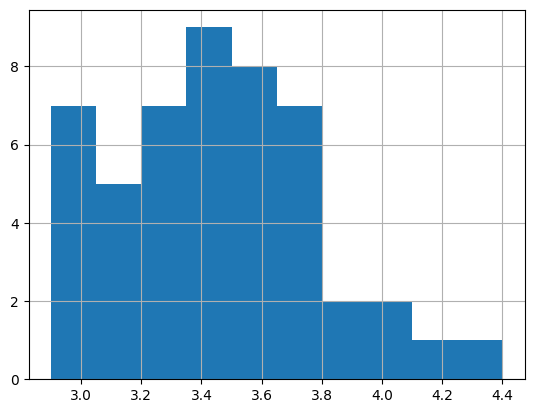

In [7]:
# This line drops any 'Iris-setosa' rows with a separal width less than 2.5 cm
iris_data = iris_data.loc[(iris_data['class'] != 'Iris-setosa') | (iris_data['sepal_width_cm'] >= 2.5)]
iris_data.loc[iris_data['class'] == 'Iris-setosa', 'sepal_width_cm'].hist()

现在我们所有的`Iris-setosa`行的萼片宽度都大于 2.5。  
下一个要解决的数据问题是`Iris-versicolor`行的几个接近零的萼片长度。让我们看一下这些行。

In [8]:
iris_data.loc[(iris_data['class'] == 'Iris-versicolor') &
              (iris_data['sepal_length_cm'] < 1.0)]

,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,class
77,0.067,3.0,5.0,1.7,Iris-versicolor
78,0.060,2.9,4.5,1.5,Iris-versicolor
79,0.057,2.6,3.5,1.0,Iris-versicolor
80,0.055,2.4,3.8,1.1,Iris-versicolor
81,0.055,2.4,3.7,1.0,Iris-versicolor


所有这些接近零的sepal_length_cm条目似乎都相差了两个数量级，就好像它们是以米而不是厘米为单位记录的。  
在与研究人员进行了一些简短的通信后，我们发现其中一位忘记将这些测量值转换为厘米。让我们为他们做这件事。  

<Axes: >

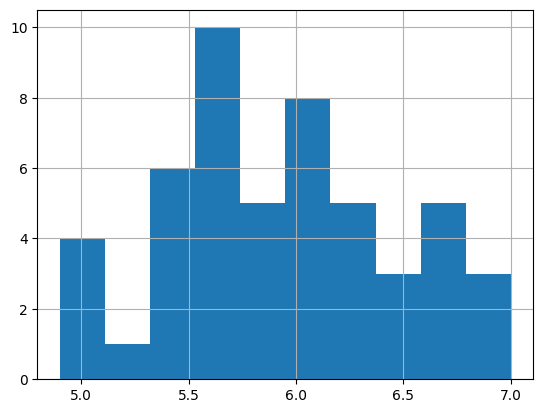

In [9]:
iris_data.loc[(iris_data['class'] == 'Iris-versicolor') &
              (iris_data['sepal_length_cm'] < 1.0),
              'sepal_length_cm'] *= 100.0

iris_data.loc[iris_data['class'] == 'Iris-versicolor', 'sepal_length_cm'].hist()

接着来看一下具有缺失值的行：

In [10]:
iris_data.loc[(iris_data['sepal_length_cm'].isnull()) |
              (iris_data['sepal_width_cm'].isnull()) |
              (iris_data['petal_length_cm'].isnull()) |
              (iris_data['petal_width_cm'].isnull())]

,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,class
7,5.0,3.4,1.5,NaN,Iris-setosa
8,4.4,2.9,1.4,NaN,Iris-setosa
9,4.9,3.1,1.5,NaN,Iris-setosa
10,5.4,3.7,1.5,NaN,Iris-setosa
11,4.8,3.4,1.6,NaN,Iris-setosa


如果只是单纯删除这些行可能并不理想，尤其是考虑到它们都是 `Iris-setosa`条目。由于缺失数据似乎是系统性的——所有缺失值都位于同一列的相同 Iris 类型中——这个错误可能会使我们的分析产生偏差。  
处理缺失数据的一种方法是**均值插补**：如果我们知道测量值在某个范围内，我们可以用该测量值的平均值填充空值。

<Axes: >

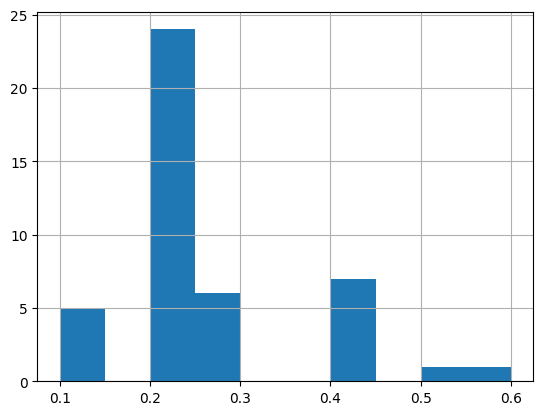

In [11]:
iris_data.loc[iris_data['class'] == 'Iris-setosa', 'petal_width_cm'].hist()

`Iris-setosa`的大部分花瓣宽度在 0.2-0.3 范围内，因此让我们用测量的平均花瓣宽度来填写这些条目。

In [12]:
average_petal_width = iris_data.loc[iris_data['class'] == 'Iris-setosa', 'petal_width_cm'].mean()

iris_data.loc[(iris_data['class'] == 'Iris-setosa') &
              (iris_data['petal_width_cm'].isnull()),
              'petal_width_cm'] = average_petal_width

iris_data.loc[(iris_data['class'] == 'Iris-setosa') &
              (iris_data['petal_width_cm'] == average_petal_width)]

,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,class
7,5.0,3.4,1.5,0.25,Iris-setosa
8,4.4,2.9,1.4,0.25,Iris-setosa
9,4.9,3.1,1.5,0.25,Iris-setosa
10,5.4,3.7,1.5,0.25,Iris-setosa
11,4.8,3.4,1.6,0.25,Iris-setosa


In [13]:
iris_data.loc[(iris_data['sepal_length_cm'].isnull()) |
              (iris_data['sepal_width_cm'].isnull()) |
              (iris_data['petal_length_cm'].isnull()) |
              (iris_data['petal_width_cm'].isnull())]

,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,class


现在通过对缺失值用均值填充，数据集中不再有缺失的数据。  
**注**：如果用不愿意插补数据，可以调用 dropna（） 删除所有缺少数据的行：  
    iris_data.dropna(inplace=True)

如果我们不想每次加载数据集时都重复上面的处理过程。可以将整理后的数据文件保存为单独的文件，并从现在开始直接使用该数据文件。

In [14]:
iris_data.to_csv('iris-data-clean.csv', index=False)

iris_data_clean = pd.read_csv('iris-data-clean.csv')

现在再来看看处理好数据后的散点图矩阵。

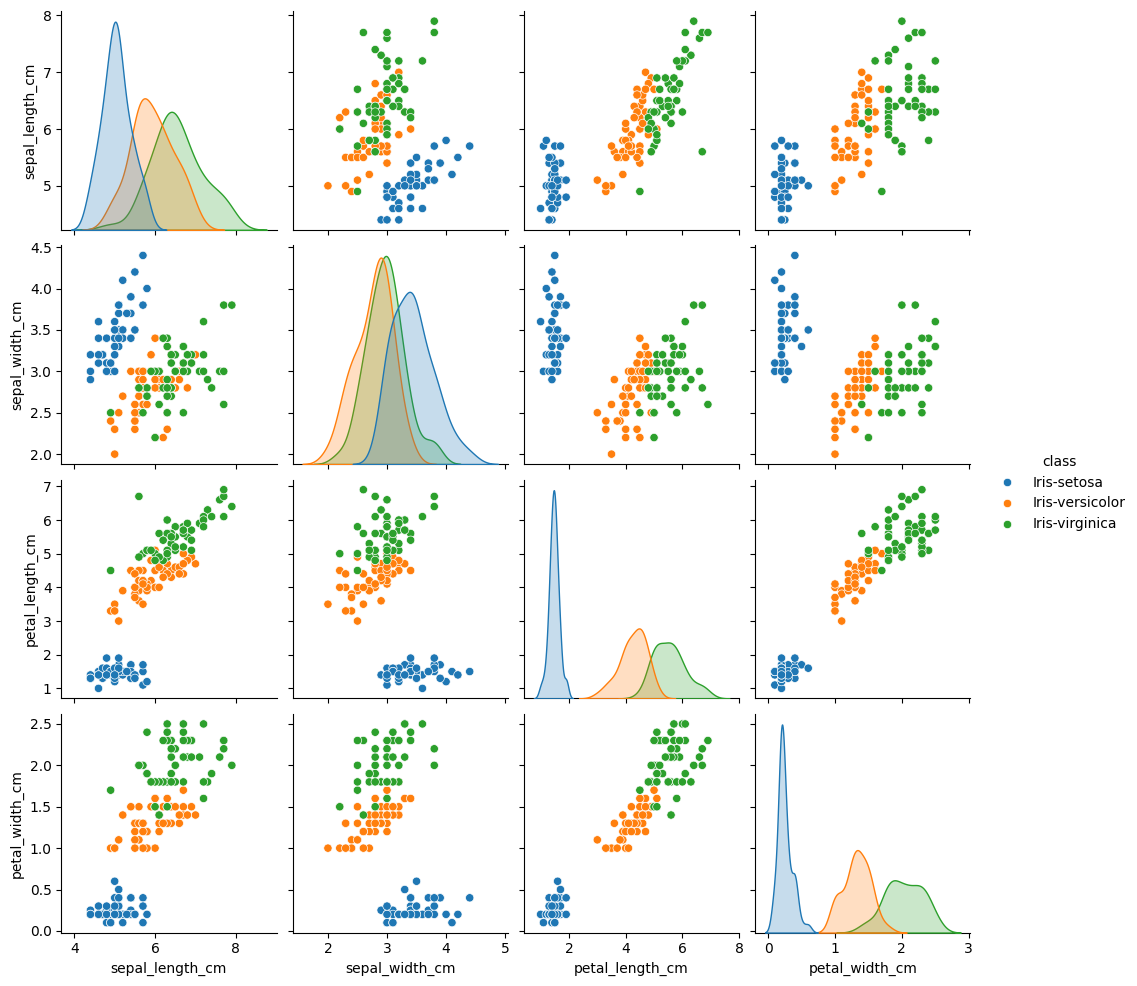

In [15]:
sb.pairplot(iris_data_clean, hue='class')

实际情况是在iris数据集中插入了许多错误，以演示整理数据时可能面临的许多可能情况中的一些情况。  
这里的一般要点应该是：
* 确保数据编码正确
* 确保数据在预期范围内，并尽可能使用领域知识来定义预期范围
* 以这样或那样的方式处理丢失的数据：如果可以的话替换它或删除它
* 永远不要手动整理数据，因为这不容易复制
* 使用代码记录如何整理数据
* 在分析的这个阶段，尽可能地绘制数据的所有内容，以便您可以直观地确认所有内容看起来都是正确的

## Step 4: 探索性分析
在整理数据之后，可以开始分析！  
探索性分析是我们开始深入研究数据集的步骤，而不是异常值和错误。我们将寻求回答以下问题：
* 数据是如何分发布的？
* 数据是否有关联？
* 是否有任何混杂因素可以解释这些相关性？
在这个阶段，应有尽可能多的方式绘制所有数据。创建许多图表，但不要费心让它们变得漂亮 - 这些图表供内部使用。  
回到我们之前使用的散点图矩阵。

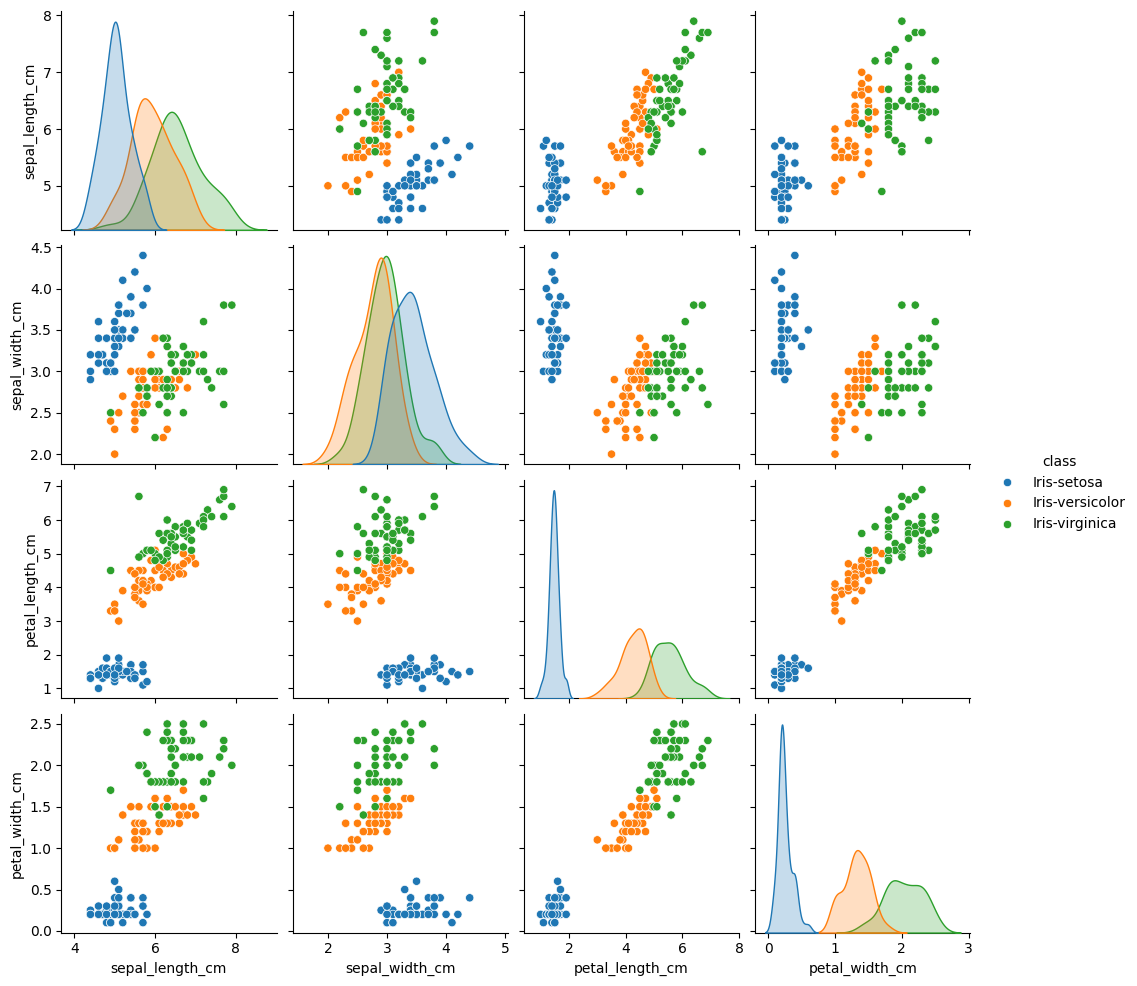

In [16]:
sb.pairplot(iris_data_clean, hue='class')

由于物种不同，花瓣测量值的奇怪分布存在。这对我们的分类任务来说实际上是个好消息，因为这意味着花瓣测量将很容易区分`Iris-setosa`和其他`Iris`类型。  
考虑到`Iris-versicolor`和`Iris-virginica`的测量值重叠程度，区分它们将更加困难。  
花瓣长度和花瓣宽度以及萼片长度和萼片宽度之间也存在相关性。野外生物学家向我们保证，这是意料之中的：较长的花瓣也往往更宽，萼片也是如此。
我们还可以制作数据的**小提琴图**，以比较类的测量分布。**Violin图**包含与**箱形图**相同的信息，但也根据数据的密度缩放**箱形图**。

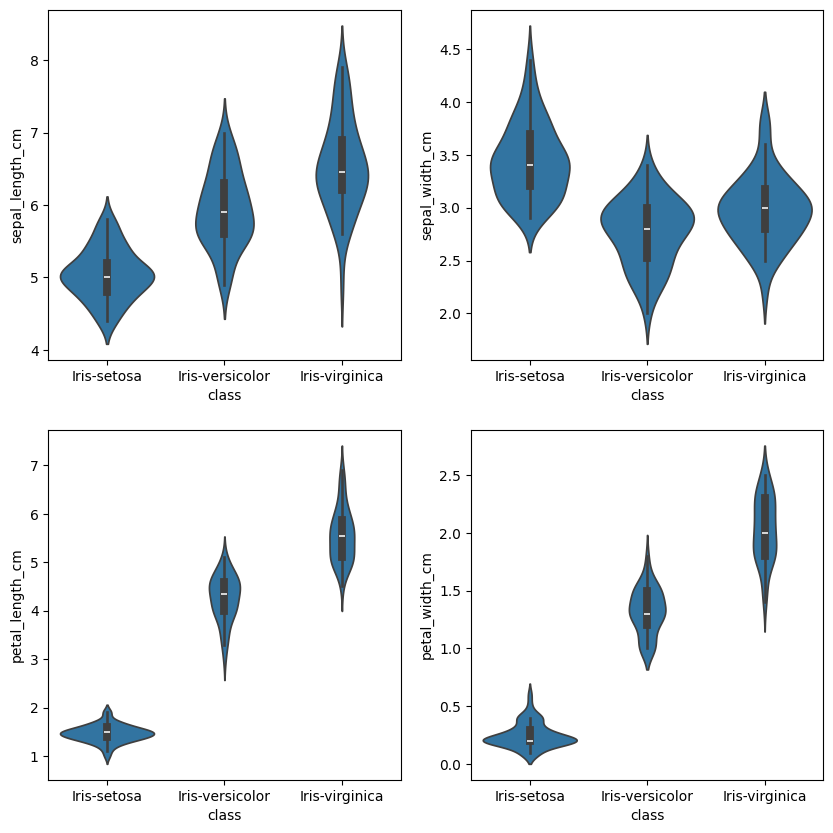

In [17]:
plt.figure(figsize=(10, 10))

for column_index, column in enumerate(iris_data_clean.columns):
    if column == 'class':
        continue
    plt.subplot(2, 2, column_index + 1)
    sb.violinplot(x='class', y=column, data=iris_data_clean)

## Step 5： 分类  
数据整理和探索是任何数据分析的重要组成部分。如果在上面的示例中，直接跳到建模步骤，肯定会得到错误的分类模型（如5个分类）。**坏数据会导致坏模型**。始终先检查您的数据。 

确保我们的数据现在已经尽可能干净了，并且对数据集中的分布和关系有一些粗略的了解，是时候在我们的分析中迈出下一个重要步骤了：将数据拆分为训练集和测试集。  
**训练集**是用于训练模型的数据的随机子集。  
**测试集**是数据的随机子集（与训练集互斥），用它来在不可预见的数据上验证模型。  

特别是在这样的稀疏数据集中，模型很容易过度拟合数据：模型将很好地学习训练集，以至于它无法处理以前从未见过的大多数情况。这就是为什么使用训练集构建模型，但使用测试集对其进行评分对我们来说很重要的原因。   
**注意**，一旦将数据拆分为训练集和测试集，应该将测试集视为不再存在：不能使用测试集中的任何信息来构建的模型，否则就是在作弊。  

In [18]:
iris_data_clean = pd.read_csv('iris-data-clean.csv')

# We're using all four measurements as inputs
# Note that scikit-learn expects each entry to be a list of values, e.g.,
# [ [val1, val2, val3],
#   [val1, val2, val3],
#   ... ]
# such that our input data set is represented as a list of lists

# We can extract the data in this format from pandas like this:
all_inputs = iris_data_clean[['sepal_length_cm', 'sepal_width_cm',
                             'petal_length_cm', 'petal_width_cm']].values

# Similarly, we can extract the classes
all_classes = iris_data_clean['class'].values

# Make sure that you don't mix up the order of the entries
# all_inputs[5] inputs should correspond to the class in all_classes[5]

# Here's what a subset of our inputs looks like:
all_inputs[:5]

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2]])

现在可以对数据进行拆分

In [20]:
from sklearn.model_selection import train_test_split

(training_inputs,
 testing_inputs,
 training_classes,
 testing_classes) = train_test_split(all_inputs, all_classes, train_size=0.75, random_state=1)

通过对数据拆分，可以使用训练集数据对分类模型进行训练。假设用**决策树分类器**。
决策树分类器在理论上非常简单。在最简单的形式中，决策树分类器会询问一系列关于数据的“是/否”问题 — 每次都更接近找出每个条目的类别 — 直到它们完美地对数据集进行分类，或者根本无法区分一组条目。把它想象成一个 [20个问题](https://en.wikipedia.org/wiki/Twenty_Questions)的游戏，只不过计算机要好得多。  
示例决策树分类器：  
<img src="iris-dtc.png" />
请注意分类器如何询问有关数据的 Yes/No 问题（例如，某个特征是否为 <= 1.75），以便区分记录。这是每个决策树的本质。

**决策树**分类器的优点是它们是尺度不变的，即与许多机器学习模型不同，特征的尺度不会影响它们的性能。换句话说，我们的特征范围是 0 到 1 还是 0 到 1,000 并不重要;决策树分类器将以相同的方式与它们一起使用。

In [21]:
from sklearn.tree import DecisionTreeClassifier

# Create the classifier
decision_tree_classifier = DecisionTreeClassifier()

# Train the classifier on the training set
decision_tree_classifier.fit(training_inputs, training_classes)

# Validate the classifier on the testing set using classification accuracy
decision_tree_classifier.score(testing_inputs, testing_classes)

0.9736842105263158

模型毫不费力地实现了 97% 的分类准确率。

根据给定的训练和测试集的采样方式，模型可以达到 80% 到 100% 的准确率：

<Axes: ylabel='Count'>

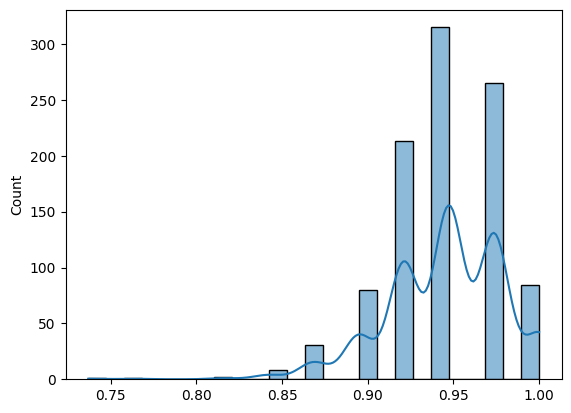

In [26]:
model_accuracies = []

for repetition in range(1000):
    (training_inputs,
     testing_inputs,
     training_classes,
     testing_classes) = train_test_split(all_inputs, all_classes, train_size=0.75)
    
    decision_tree_classifier = DecisionTreeClassifier()
    decision_tree_classifier.fit(training_inputs, training_classes)
    classifier_accuracy = decision_tree_classifier.score(testing_inputs, testing_classes)
    model_accuracies.append(classifier_accuracy)
    
#sb.distplot(model_accuracies)
sb.histplot(model_accuracies, kde=True)

显然，我们的模型根据训练的数据子集执行完全不同的操作，这显然是一个问题。这种现象称为**过拟合**：该模型正在学习对训练集进行分类，以至于它无法对以前从未见过的数据进行泛化和表现良好。

### 交叉验证

这个问题是大多数数据科学家对他们的模型执行**k折交叉验证**的主要原因：将原始数据集拆分为 k 个子集，使用其中一个子集作为测试集，其余子集用作训练集。然后重复此过程 k 次，以便每个子集仅用作测试集一次。

10 倍交叉验证是最常见的选择，因此让我们在这里使用它。对我们的数据集执行 10 倍交叉验证如下所示：  
（每个方块都是我们数据集中的一个条目）

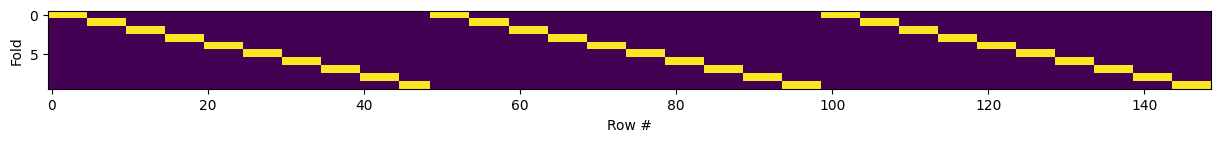

In [46]:
import numpy as np
from sklearn.model_selection import StratifiedKFold

def plot_cv(cv, inputs, classes):
    masks = []
    for train, test in cv.split(inputs, classes):
        mask = np.zeros(len(all_classes), dtype=bool)
        mask[test] = 1
        masks.append(mask)
        
    plt.figure(figsize=(15, 15))
    plt.imshow(masks, interpolation='none')
    plt.ylabel('Fold')
    plt.xlabel('Row #')

plot_cv(StratifiedKFold(n_splits=10), all_inputs, all_classes)

我们在上面的代码中使用了**Stratified k-fold交叉验证**。分层k折叠使所有折叠的类比例保持相同，这对于维护我们数据集的代表性子集至关重要。（例如，因此我们在其中一个折叠中没有 100% 的 Iris setosa 条目。  
可以使用以下代码对模型执行 10 倍交叉验证：

Text(0.5, 1.0, 'Average score: 0.96')

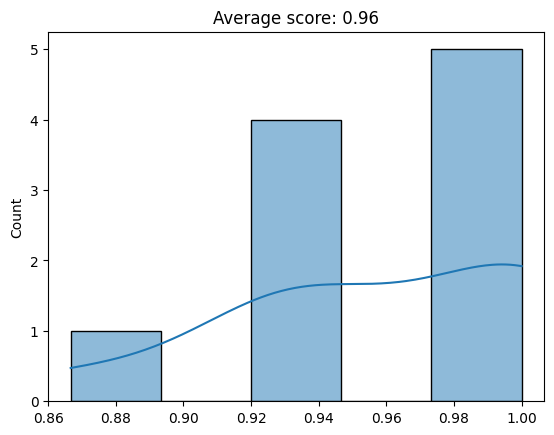

In [44]:
from sklearn.model_selection import cross_val_score

decision_tree_classifier = DecisionTreeClassifier()

# cross_val_score returns a list of the scores, which we can visualize
# to get a reasonable estimate of our classifier's performance
cv_scores = cross_val_score(decision_tree_classifier, all_inputs, all_classes, cv=10)
# sb.distplot(cv_scores)
sb.histplot(cv_scores, kde=True)

plt.title('Average score: {}'.format(np.mean(cv_scores)))

这样就有了对分类器的一般分类准确性有了更一致的评级。

### 参数调优

每个 Machine Learning 模型都带有各种需要调整的参数，这些参数对于分类器的性能至关重要。例如，如果严格限制决策树分类器的深度（下面是深度为1）：  

Text(0.5, 1.0, 'Average score: 0.6642857142857144')

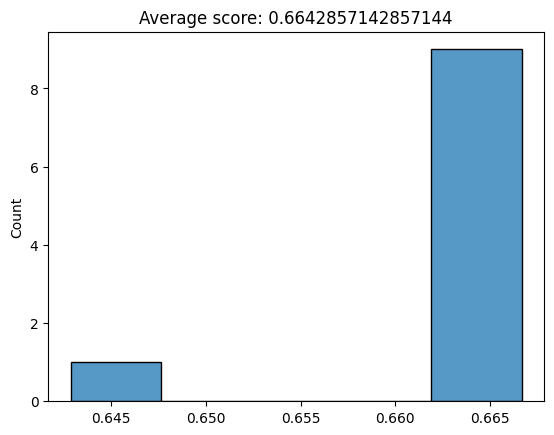

In [48]:
decision_tree_classifier = DecisionTreeClassifier(max_depth=1)

cv_scores = cross_val_score(decision_tree_classifier, all_inputs, all_classes, cv=10)
sb.histplot(cv_scores, kde=False)
plt.title('Average score: {}'.format(np.mean(cv_scores)))

此时分类准确性大大下降（只有66.5%）。  
因此，需要找到一种系统的方法来发现我们的模型和数据集的最佳参数。 
模型参数调整的最常见方法是**Grid Search**。网格搜索背后的想法很简单：探索一系列参数并找到性能最佳的参数组合。将搜索重点放在最佳参数范围内，然后重复此过程几次，直到找到最佳参数。  
让我们调整我们的决策树分类器。我们现在只坚持使用两个参数，但如果需要，可以同时探索数更多参数。  

In [52]:
from sklearn.model_selection import GridSearchCV

decision_tree_classifier = DecisionTreeClassifier()

parameter_grid = {'max_depth': [1, 2, 3, 4, 5],
                  'max_features': [1, 2, 3, 4]}

cross_validation = StratifiedKFold(n_splits=10)

grid_search = GridSearchCV(decision_tree_classifier,
                           param_grid=parameter_grid,
                           cv=cross_validation)

grid_search.fit(all_inputs, all_classes)
print('Best score: {}'.format(grid_search.best_score_))
print('Best parameters: {}'.format(grid_search.best_params_))

Best score: 0.96
Best parameters: {'max_depth': 3, 'max_features': 4}


可视化网格搜索，看看参数如何交互。

Text(50.722222222222214, 0.5, 'max_depth')

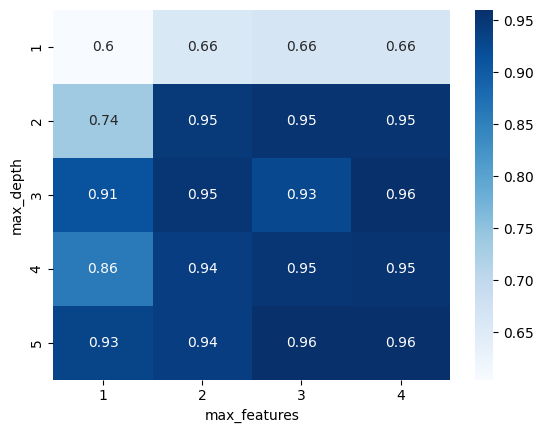

In [54]:
grid_visualization = grid_search.cv_results_['mean_test_score']
grid_visualization.shape = (5, 4)
sb.heatmap(grid_visualization, cmap='Blues', annot=True)
plt.xticks(np.arange(4) + 0.5, grid_search.param_grid['max_features'])
plt.yticks(np.arange(5) + 0.5, grid_search.param_grid['max_depth'])
plt.xlabel('max_features')
plt.ylabel('max_depth')

现在我们对参数空间有了更好的了解：我们知道我们需要至少 2 的 max_depth 才能让决策树做出多个一次性决策。
只要我们有 2 个特征，`max_features`似乎就没有太大的区别，这是有道理的，因为我们的数据集只有 4 个特征，而且相对容易分类。（请记住，我们数据集的一个类很容易根据单个特征与其他类分开。   
我们继续使用广泛的网格搜索来查找一些参数的最佳设置。  

In [56]:
decision_tree_classifier = DecisionTreeClassifier()

parameter_grid = {'criterion': ['gini', 'entropy'],
                  'splitter': ['best', 'random'],
                  'max_depth': [1, 2, 3, 4, 5],
                  'max_features': [1, 2, 3, 4]}

cross_validation = StratifiedKFold(n_splits=10)

grid_search = GridSearchCV(decision_tree_classifier,
                           param_grid=parameter_grid,
                           cv=cross_validation)

grid_search.fit(all_inputs, all_classes)
print('Best score: {}'.format(grid_search.best_score_))
print('Best parameters: {}'.format(grid_search.best_params_))

Best score: 0.9666666666666668
Best parameters: {'criterion': 'gini', 'max_depth': 4, 'max_features': 4, 'splitter': 'random'}


现在我们可以从网格搜索中选取最佳分类器并使用它：

In [57]:
decision_tree_classifier = grid_search.best_estimator_
decision_tree_classifier

DecisionTreeClassifier(max_depth=4, max_features=4, splitter='random')

我们甚至可以使用[GraphViz](http://www.graphviz.org/)可视化决策树，看看它是如何进行分类的：

In [59]:
import sklearn.tree as tree
from io import StringIO

with open('iris-dtc.dot', 'w') as out_file:
    out_file = tree.export_graphviz(decision_tree_classifier, out_file=out_file)

<img src="iris-dtc.png" />

最终有了 demo 分类器。让我们创建一些其性能的可视化，以便我们有一些东西可以向客户/老板展示。

<Axes: >

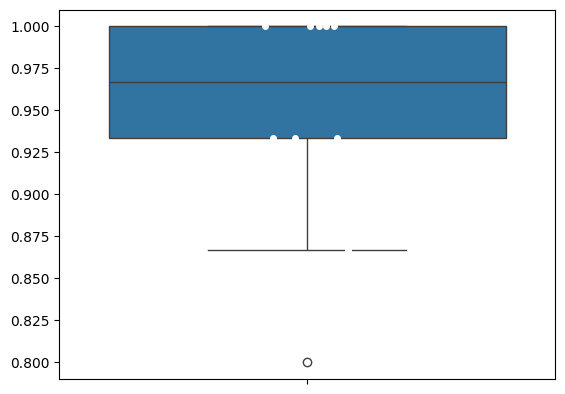

In [60]:
dt_scores = cross_val_score(decision_tree_classifier, all_inputs, all_classes, cv=10)

sb.boxplot(dt_scores)
sb.stripplot(dt_scores, jitter=True, color='white')

我们比较另一个分类器看看它们的表现如何？  
根据经验，随机森林分类器通常比单个决策树效果更好。决策树面临的一个常见问题是它们容易过度拟合：它们复杂化到对训练集近乎完美的分类，但无法推广到以前从未见过的数据。  
**随机森林分类器**通过创建一大堆决策树（因此称为“森林”）来解决这一限制，每个决策树都针对训练样本（使用替换绘制）和特征（绘制时未替换）的随机子集进行训练，并让决策树协同工作以做出更准确的分类。
让我们看看 Random Forest 分类器在这里是否效果更好。  
**scikit-learn**的一大优点是，所有模型的训练、测试、参数调整等过程都是相同的，因此我们只需要插入新的分类器即可。  

In [62]:
from sklearn.ensemble import RandomForestClassifier

random_forest_classifier = RandomForestClassifier()

parameter_grid = {'n_estimators': [5, 10, 25, 50],
                  'criterion': ['gini', 'entropy'],
                  'max_features': [1, 2, 3, 4],
                  'warm_start': [True, False]}

cross_validation = StratifiedKFold(n_splits=10)

grid_search = GridSearchCV(random_forest_classifier,
                           param_grid=parameter_grid,
                           cv=cross_validation)

grid_search.fit(all_inputs, all_classes)
print('Best score: {}'.format(grid_search.best_score_))
print('Best parameters: {}'.format(grid_search.best_params_))

grid_search.best_estimator_

Best score: 0.9666666666666666
Best parameters: {'criterion': 'gini', 'max_features': 1, 'n_estimators': 50, 'warm_start': True}


RandomForestClassifier(max_features=1, n_estimators=50, warm_start=True)

比较它们的性能：

<Axes: xlabel='classifier', ylabel='accuracy'>

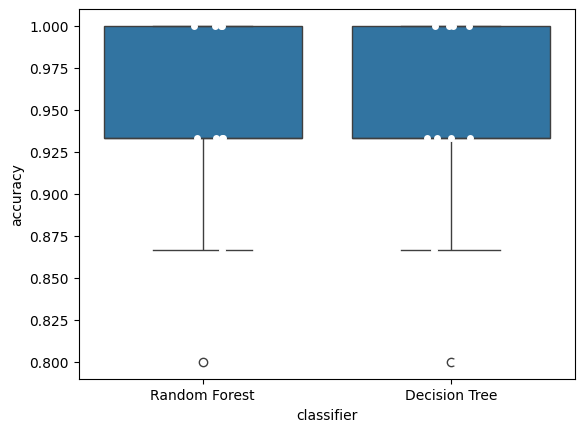

In [64]:
random_forest_classifier = grid_search.best_estimator_

rf_df = pd.DataFrame({'accuracy': cross_val_score(random_forest_classifier, all_inputs, all_classes, cv=10),
                       'classifier': ['Random Forest'] * 10})
dt_df = pd.DataFrame({'accuracy': cross_val_score(decision_tree_classifier, all_inputs, all_classes, cv=10),
                      'classifier': ['Decision Tree'] * 10})
both_df = pd.concat([rf_df, dt_df])

sb.boxplot(x='classifier', y='accuracy', data=both_df)
sb.stripplot(x='classifier', y='accuracy', data=both_df, jitter=True, color='white')

两种分类模型的表现大致相同。这可能是因为数据集的局限性：我们只有 4 个特征可以进行分类，当有数百个可能的特征需要查看时，随机森林分类器会表现出色。换句话说，这个数据集没有太大的改进空间。

## Step 6: 重现性
确保工作是可重复的，是任何分析中最后的一步，也可以说是最重要的一步。**通常，不应该对无法复制的发现给予太大的重视。**因此，如果分析不可重现，可能就不做。  

像这样的Notebook对使我们的工作具有可重复性大有帮助。由于在前进过程中记录了每一步，因此以文本和代码的形式记录了所做的工作以及我们为什么这样做。  
除了记录所做的工作外，通常位于Notebook的顶部记录使用哪些软件和硬件来执行分析。这样可以便使用者知道该使用什么工具。

最后，让我们从步骤 1-5 中提取我们工作的核心，并将其转换为单个管道。

[6.9 3.2 5.7 2.3]	-->	Iris-virginica	(Actual: Iris-virginica)
[7.2 3.  5.8 1.6]	-->	Iris-virginica	(Actual: Iris-virginica)
[5.9 3.  5.1 1.8]	-->	Iris-virginica	(Actual: Iris-virginica)
[6.5 2.8 4.6 1.5]	-->	Iris-versicolor	(Actual: Iris-versicolor)
[4.6 3.2 1.4 0.2]	-->	Iris-setosa	(Actual: Iris-setosa)
[6.3 3.3 6.  2.5]	-->	Iris-virginica	(Actual: Iris-virginica)
[5.8 2.8 5.1 2.4]	-->	Iris-virginica	(Actual: Iris-virginica)
[5.6 2.8 4.9 2. ]	-->	Iris-virginica	(Actual: Iris-virginica)
[5.7 3.  4.2 1.2]	-->	Iris-versicolor	(Actual: Iris-versicolor)
[5.6 3.  4.1 1.3]	-->	Iris-versicolor	(Actual: Iris-versicolor)


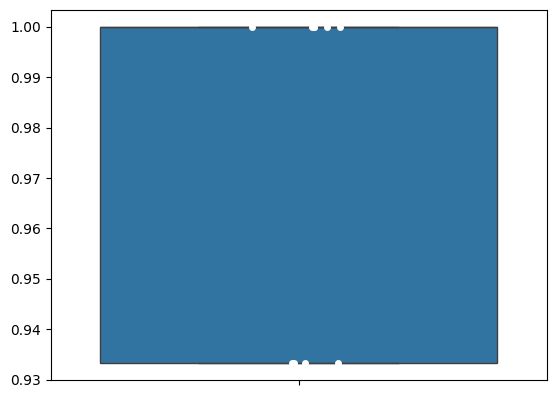

In [65]:
%matplotlib inline
import pandas as pd
import seaborn as sb
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

# We can jump directly to working with the clean data because we saved our cleaned data set
iris_data_clean = pd.read_csv('iris-data-clean.csv')

# Testing our data: Our analysis will stop here if any of these assertions are wrong

# We know that we should only have three classes
assert len(iris_data_clean['class'].unique()) == 3

# We know that sepal lengths for 'Iris-versicolor' should never be below 2.5 cm
assert iris_data_clean.loc[iris_data_clean['class'] == 'Iris-versicolor', 'sepal_length_cm'].min() >= 2.5

# We know that our data set should have no missing measurements
assert len(iris_data_clean.loc[(iris_data_clean['sepal_length_cm'].isnull()) |
                               (iris_data_clean['sepal_width_cm'].isnull()) |
                               (iris_data_clean['petal_length_cm'].isnull()) |
                               (iris_data_clean['petal_width_cm'].isnull())]) == 0

all_inputs = iris_data_clean[['sepal_length_cm', 'sepal_width_cm',
                             'petal_length_cm', 'petal_width_cm']].values

all_classes = iris_data_clean['class'].values

# This is the classifier that came out of Grid Search
random_forest_classifier = RandomForestClassifier(bootstrap=True, class_weight=None, criterion='gini',
                                max_depth=None, max_features=3, max_leaf_nodes=None,
                                min_samples_leaf=1, min_samples_split=2,
                                min_weight_fraction_leaf=0.0, n_estimators=5, n_jobs=1,
                                oob_score=False, random_state=None, verbose=0, warm_start=True)

# All that's left to do now is plot the cross-validation scores
rf_classifier_scores = cross_val_score(random_forest_classifier, all_inputs, all_classes, cv=10)
sb.boxplot(rf_classifier_scores)
sb.stripplot(rf_classifier_scores, jitter=True, color='white')

# ...and show some of the predictions from the classifier
(training_inputs,
 testing_inputs,
 training_classes,
 testing_classes) = train_test_split(all_inputs, all_classes, train_size=0.75)

random_forest_classifier.fit(training_inputs, training_classes)

for input_features, prediction, actual in zip(testing_inputs[:10],
                                              random_forest_classifier.predict(testing_inputs[:10]),
                                              testing_classes[:10]):
    print('{}\t-->\t{}\t(Actual: {})'.format(input_features, prediction, actual))

以上是一个完整且可重现的机器学习程序输出！